In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display
from qutip import spin_Jx, spin_Jy, spin_Jz, spin_coherent
from scipy.linalg import expm

In [13]:
J = 4.5
J_x = spin_Jx(J).full()
J_y = spin_Jy(J).full()
J_z = spin_Jz(J).full()
def expect(obs, state):
    """Compute the expectation value of an observable."""
    return np.real(np.trace(obs @ state))

def bloch_coordinates(state):
    """Compute the Bloch coordinates of a state."""
    x = expect(J_x, state)
    y = expect(J_y, state)
    z = expect(J_z, state)
    return np.array([x, y, z])/J

def fibonacci_sphere(N):
    i = np.arange(N)
    phi = 2 * np.pi * (i / ((1 + np.sqrt(5)) / 2) % 1)
    z = 1 - 2*(i + 0.5)/N
    theta = np.arccos(z)
    return theta, phi

def geodesic_distance(v1, v2):
    return np.arccos(np.clip(np.dot(v1, v2), -1.0, 1.0))

def distance_matrix(vectors):
    N = len(vectors)
    D = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            if i != j:
                D[i, j] = geodesic_distance(vectors[i], vectors[j])
    return D

def nearest_neighbor_tsp(D):
    N = len(D)
    visited = [0]
    remaining = set(range(1, N))

    while remaining:
        last = visited[-1]
        next_city = min(remaining, key=lambda j: D[last, j])
        visited.append(next_city)
        remaining.remove(next_city)

    return visited

def two_opt(path, D):
    improved = True
    N = len(path)
    while improved:
        improved = False
        for i in range(1, N - 2):
            for j in range(i + 1, N):
                if j - i == 1:
                    continue
                a, b = path[i - 1], path[i]
                c, d = path[j - 1], path[j % N]

                if D[a, b] + D[c, d] > D[a, c] + D[b, d]:
                    path[i:j] = reversed(path[i:j])
                    improved = True
    return path



In [20]:
N_points = 20
theta, phi = fibonacci_sphere(N_points)
fibonacci_vectors = [np.array([np.sin(theta[i]) * np.cos(phi[i]), np.sin(theta[i]) * np.sin(phi[i]), np.cos(theta[i])]) for i in range(N_points)]
D = distance_matrix(fibonacci_vectors)
path = nearest_neighbor_tsp(D)
path = two_opt(path, D)
optimized_vectors = [fibonacci_vectors[i] for i in path]
rotation_angle = [
    geodesic_distance(optimized_vectors[i], optimized_vectors[i+1])
    for i in range(len(optimized_vectors)-1)
]

cross_fibonacci = [
    np.cross(optimized_vectors[i], optimized_vectors[i+1]) /
    np.linalg.norm(np.cross(optimized_vectors[i], optimized_vectors[i+1]))
    for i in range(len(optimized_vectors)-1)
]
in_state = spin_coherent(J, theta[0], phi[0], type = 'dm').full()
state = in_state
delta_t = 0.001
t_steps = 7000
t_global = 0
w = np.random.normal(0, 0.01, 3)
#w = [0.12, 0.04, 0.04]
bloch_array = [None] * (t_steps + 1)
bloch_array[0] = bloch_coordinates(state)
U_w = expm(-1j * (w[0] * J_x + w[1] * J_y + w[2] * J_z) * delta_t)
U_w_dagger = expm(1j * (w[0] * J_x + w[1] * J_y + w[2] * J_z) * delta_t)

for cross_idx, cross in enumerate(cross_fibonacci):
    if cross_idx == len(cross_fibonacci) - 1:
        t_per_cross = t_steps - t_global
    else:
        t_per_cross = t_steps // len(cross_fibonacci)
    omega_cross = rotation_angle[cross_idx] / (t_per_cross * delta_t)
    U = expm(-1j * (cross[0] * J_x + cross[1] * J_y + cross[2] * J_z) * delta_t * omega_cross)
    U_dagger = expm(1j * (cross[0] * J_x + cross[1] * J_y + cross[2] * J_z) * delta_t * omega_cross)
    for i in range(t_per_cross):
        t_global += 1
        state = U_w @ U @ state @ U_dagger @ U_w_dagger
        bloch_array[t_global] = bloch_coordinates(state)

bloch_array = np.array(bloch_array)

In [21]:
print(rotation_angle)

[0.7045917003327643, 0.7503591819519269, 0.7540166463724575, 0.7757979594887745, 0.7448599457124506, 0.7505802794456096, 0.7523937368910036, 0.799738308998274, 0.7555858595981384, 0.7546365125653403, 0.7555858595981375, 0.7516599493835343, 0.704591700332764, 0.7503591819519269, 0.7540166463724588, 0.7757979594887736, 0.7448599457124516, 0.7505802794456116, 0.7523937368910019]


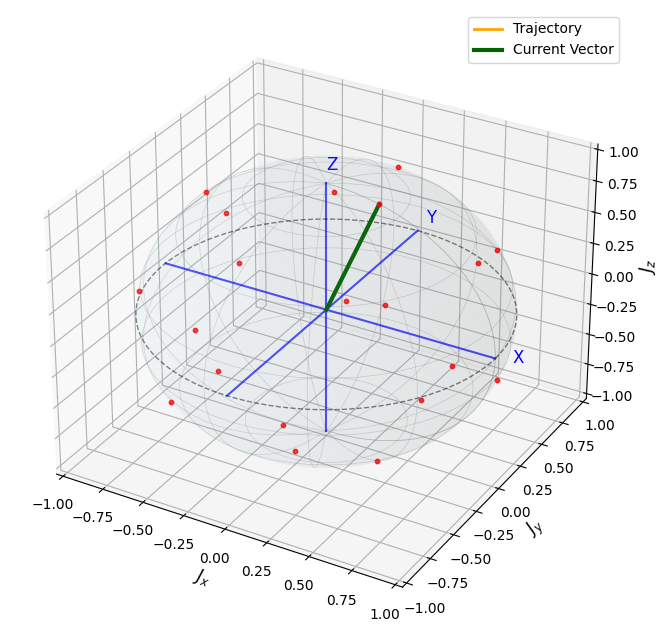

In [22]:
t = 50
Jx = bloch_array[:,0][0::t]
Jy = bloch_array[:,1][0::t]
Jz = bloch_array[:,2][0::t]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")

# Set axis limits and labels
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_xlabel(r"$J_x$", fontsize=12)
ax.set_ylabel(r"$J_y$", fontsize=12)
ax.set_zlabel(r"$J_z$", fontsize=12)

# Add a grid for better depth perception
ax.grid(True, alpha=0.3)

# Draw Bloch sphere with wireframe
u = np.linspace(0, 2*np.pi, 50)
v = np.linspace(0, np.pi, 50)
xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))

# Draw sphere with low alpha and wireframe
ax.plot_surface(xs, ys, zs, alpha=0.05, color='lightblue', linewidth=0, antialiased=True)

# Add longitude lines (vertical great circles)
for phi in np.linspace(0, 2*np.pi, 12):
    x = np.cos(phi) * np.sin(np.linspace(0, np.pi, 50))
    y = np.sin(phi) * np.sin(np.linspace(0, np.pi, 50))
    z = np.cos(np.linspace(0, np.pi, 50))
    ax.plot(x, y, z, color='gray', alpha=0.3, linewidth=0.5)

# Add latitude lines (horizontal circles)
for theta in np.linspace(0, np.pi, 8)[1:-1]:  # Skip poles
    r = np.sin(theta)
    z_val = np.cos(theta)
    phi = np.linspace(0, 2*np.pi, 50)
    x = r * np.cos(phi)
    y = r * np.sin(phi)
    z = np.ones_like(phi) * z_val
    ax.plot(x, y, z, color='gray', alpha=0.3, linewidth=0.5)

# Draw coordinate axes with labels
# X-axis (red)
ax.plot([-1, 1], [0, 0], [0, 0], color='blue', alpha=0.7, linewidth=1.5)
ax.text(1.1, 0, 0, 'X', color='blue', fontsize=12)

# Y-axis (green)
ax.plot([0, 0], [-1, 1], [0, 0], color='blue', alpha=0.7, linewidth=1.5)
ax.text(0, 1.1, 0, 'Y', color='blue', fontsize=12)

# Z-axis (blue)
ax.plot([0, 0], [0, 0], [-1, 1], color='blue', alpha=0.7, linewidth=1.5)
ax.text(0, 0, 1.1, 'Z', color='blue', fontsize=12)

#Add platonic solid vertices
for vertex in fibonacci_vectors:
    ax.scatter(vertex[0], vertex[1], vertex[2], color='red', s=10, alpha=0.8)

# Add equator line (special highlight)
phi_eq = np.linspace(0, 2*np.pi, 100)
x_eq = np.cos(phi_eq)
y_eq = np.sin(phi_eq)
z_eq = np.zeros_like(phi_eq)
ax.plot(x_eq, y_eq, z_eq, color='black', alpha=0.5, linewidth=1, linestyle='--')


# Trajectory + vector
traj, = ax.plot([], [], [], lw=2, color='orange', label='Trajectory')
vec, = ax.plot([], [], [], lw=3, color='darkgreen', label='Current Vector')

# Add legend
ax.legend(loc='upper right')

def update(frame):
    traj.set_data(Jx[:frame], Jy[:frame])
    traj.set_3d_properties(Jz[:frame])
    vec.set_data([0, Jx[frame]], [0, Jy[frame]])
    vec.set_3d_properties([0, Jz[frame]])
    return traj, vec

ani = animation.FuncAnimation(fig, update, frames=len(Jx), interval=40)
ani.save(f'bloch_vector.mp4', writer='ffmpeg', fps=30, dpi=200)
#display(HTML(ani.to_jshtml()))